In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import warnings
warnings.filterwarnings("ignore")

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [4]:
import os

print(os.getcwd())
print(os.listdir())
print(os.listdir("data"))

c:\Users\Puspal\OneDrive\Desktop\AeroGuard
['data', 'model.ipynb']
['RUL_FD001.txt', 'test_FD001.txt', 'train_FD001.txt']


In [ ]:
import pandas as pd

# NASA C-MAPSS FD001 column names
columns = (
    ["unit_id", "cycle", "setting_1", "setting_2", "setting_3"]
    + [f"sensor_{i}" for i in range(1, 22)]
)

# Load training data
train_df = pd.read_csv(
    "data/train_FD001.txt",
    sep=r"\s+",
    header=None,
    names=columns
)

# Load test data
test_df = pd.read_csv(
    "data/test_FD001.txt",
    sep=r"\s+",
    header=None,
    names=columns
)

# Load actual RUL values for test engines
rul_df = pd.read_csv(
    "data/RUL_FD001.txt",
    sep=r"\s+",
    header=None,
    names=["RUL"]
)

print("Training data:", train_df.shape)
print("Test data:", test_df.shape)
print("RUL data:", rul_df.shape)

Training data: (20631, 26)
Test data: (13096, 26)
RUL data: (100, 1)


In [6]:
train_df.head()

,unit_id,cycle,setting_1,setting_2,setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [7]:
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20631 entries, 0 to 20630
Data columns (total 26 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   unit_id    20631 non-null  int64  
 1   cycle      20631 non-null  int64  
 2   setting_1  20631 non-null  float64
 3   setting_2  20631 non-null  float64
 4   setting_3  20631 non-null  float64
 5   sensor_1   20631 non-null  float64
 6   sensor_2   20631 non-null  float64
 7   sensor_3   20631 non-null  float64
 8   sensor_4   20631 non-null  float64
 9   sensor_5   20631 non-null  float64
 10  sensor_6   20631 non-null  float64
 11  sensor_7   20631 non-null  float64
 12  sensor_8   20631 non-null  float64
 13  sensor_9   20631 non-null  float64
 14  sensor_10  20631 non-null  float64
 15  sensor_11  20631 non-null  float64
 16  sensor_12  20631 non-null  float64
 17  sensor_13  20631 non-null  float64
 18  sensor_14  20631 non-null  float64
 19  sensor_15  20631 non-null  float64
 20  sensor_16  20631 

In [8]:
train_df.describe()

,unit_id,cycle,setting_1,setting_2,setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
count,20631.000000,20631.000000,20631.000000,20631.000000,20631.0,20631.00,20631.000000,20631.000000,20631.000000,2.063100e+04,...,20631.000000,20631.000000,20631.000000,20631.000000,2.063100e+04,20631.000000,20631.0,20631.0,20631.000000,20631.000000
mean,51.506568,108.807862,-0.000009,0.000002,100.0,518.67,642.680934,1590.523119,1408.933782,1.462000e+01,...,521.413470,2388.096152,8143.752722,8.442146,3.000000e-02,393.210654,2388.0,100.0,38.816271,23.289705
std,29.227633,68.880990,0.002187,0.000293,0.0,0.00,0.500053,6.131150,9.000605,1.776400e-15,...,0.737553,0.071919,19.076176,0.037505,1.387812e-17,1.548763,0.0,0.0,0.180746,0.108251
min,1.000000,1.000000,-0.008700,-0.000600,100.0,518.67,641.210000,1571.040000,1382.250000,1.462000e+01,...,518.690000,2387.880000,8099.940000,8.324900,3.000000e-02,388.000000,2388.0,100.0,38.140000,22.894200
25%,26.000000,52.000000,-0.001500,-0.000200,100.0,518.67,642.325000,1586.260000,1402.360000,1.462000e+01,...,520.960000,2388.040000,8133.245000,8.414900,3.000000e-02,392.000000,2388.0,100.0,38.700000,23.221800
50%,52.000000,104.000000,0.000000,0.000000,100.0,518.67,642.640000,1590.100000,1408.040000,1.462000e+01,...,521.480000,2388.090000,8140.540000,8.438900,3.000000e-02,393.000000,2388.0,100.0,38.830000,23.297900
75%,77.000000,156.000000,0.001500,0.000300,100.0,518.67,643.000000,1594.380000,1414.555000,1.462000e+01,...,521.950000,2388.140000,8148.310000,8.465600,3.000000e-02,394.000000,2388.0,100.0,38.950000,23.366800
max,100.000000,362.000000,0.008700,0.000600,100.0,518.67,644.530000,1616.910000,1441.490000,1.462000e+01,...,523.380000,2388.560000,8293.720000,8.584800,3.000000e-02,400.000000,2388.0,100.0,39.430000,23.618400


In [11]:
missing_values = train_df.isnull().sum()

print(missing_values)

unit_id      0
cycle        0
setting_1    0
setting_2    0
setting_3    0
sensor_1     0
sensor_2     0
sensor_3     0
sensor_4     0
sensor_5     0
sensor_6     0
sensor_7     0
sensor_8     0
sensor_9     0
sensor_10    0
sensor_11    0
sensor_12    0
sensor_13    0
sensor_14    0
sensor_15    0
sensor_16    0
sensor_17    0
sensor_18    0
sensor_19    0
sensor_20    0
sensor_21    0
dtype: int64


In [12]:
print("\nTotal missing values:", train_df.isnull().sum().sum())


Total missing values: 0


In [13]:
print("Number of engines:", train_df["unit_id"].nunique())

print("\nCycles per engine:")
print(train_df.groupby("unit_id")["cycle"].max().head(10))

Number of engines: 100

Cycles per engine:
unit_id
1     192
2     287
3     179
4     189
5     269
6     188
7     259
8     150
9     201
10    222
Name: cycle, dtype: int64


In [14]:
# Calculate the maximum cycle reached by each engine

max_cycle = train_df.groupby("unit_id")["cycle"].max()

# Calculate Remaining Useful Life (RUL)
train_df["RUL"] = train_df.apply(
    lambda row: max_cycle[row["unit_id"]] - row["cycle"],
    axis=1
)

# Display the result
train_df[["unit_id", "cycle", "RUL"]].head(10)

,unit_id,cycle,RUL
0,1,1,191.0
1,1,2,190.0
2,1,3,189.0
3,1,4,188.0
4,1,5,187.0
5,1,6,186.0
6,1,7,185.0
7,1,8,184.0
8,1,9,183.0
9,1,10,182.0


In [15]:
print("Maximum RUL:", train_df["RUL"].max())
print("Minimum RUL:", train_df["RUL"].min())

print("\nRUL statistics:")
print(train_df["RUL"].describe())

Maximum RUL: 361.0
Minimum RUL: 0.0

RUL statistics:
count    20631.000000
mean       107.807862
std         68.880990
min          0.000000
25%         51.000000
50%        103.000000
75%        155.000000
max        361.000000
Name: RUL, dtype: float64


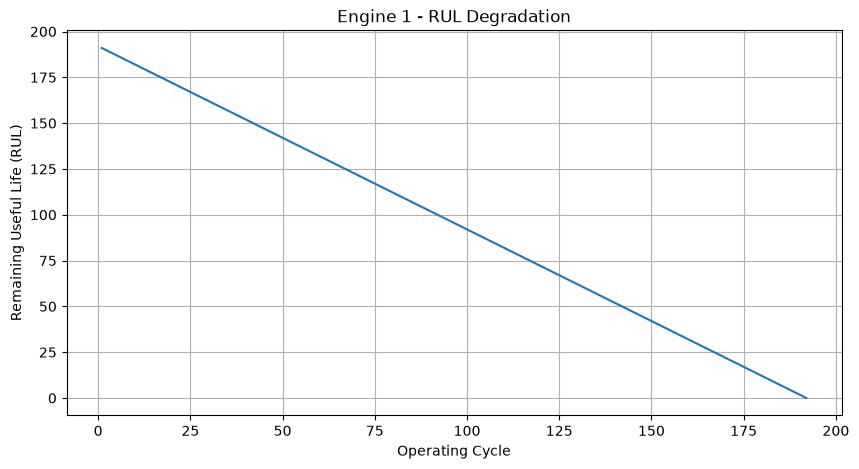

In [ ]:
engine_id = 1

engine_data = train_df[train_df["unit_id"] == engine_id]

plt.figure(figsize=(10, 5))

plt.plot(
    engine_data["cycle"],
    engine_data["RUL"]
)

plt.xlabel("Operating Cycle")
plt.ylabel("Remaining Useful Life (RUL)")
plt.title(f"Engine {engine_id} - RUL Degradation")

plt.grid(True)
plt.show()

In [17]:
# Check how much each sensor varies

sensor_columns = [f"sensor_{i}" for i in range(1, 22)]

sensor_std = train_df[sensor_columns].std().sort_values()

print(sensor_std)

sensor_1     0.000000e+00
sensor_10    0.000000e+00
sensor_19    0.000000e+00
sensor_18    0.000000e+00
sensor_16    1.387812e-17
sensor_5     1.776400e-15
sensor_6     1.388985e-03
sensor_15    3.750504e-02
sensor_8     7.098548e-02
sensor_13    7.191892e-02
sensor_21    1.082509e-01
sensor_20    1.807464e-01
sensor_11    2.670874e-01
sensor_2     5.000533e-01
sensor_12    7.375534e-01
sensor_7     8.850923e-01
sensor_17    1.548763e+00
sensor_3     6.131150e+00
sensor_4     9.000605e+00
sensor_14    1.907618e+01
sensor_9     2.208288e+01
dtype: float64


In [18]:
# Sensors with very little variation

constant_sensors = sensor_std[sensor_std < 0.01].index.tolist()

print("Nearly constant sensors:")
print(constant_sensors)

print("\nNumber of nearly constant sensors:", len(constant_sensors))

Nearly constant sensors:
['sensor_1', 'sensor_10', 'sensor_19', 'sensor_18', 'sensor_16', 'sensor_5', 'sensor_6']

Number of nearly constant sensors: 7


In [19]:
# Correlation between sensors and RUL

correlations = (
    train_df[sensor_columns + ["RUL"]]
    .corr()["RUL"]
    .drop("RUL")
    .sort_values()
)

print(correlations)

sensor_11   -0.696228
sensor_4    -0.678948
sensor_15   -0.642667
sensor_2    -0.606484
sensor_17   -0.606154
sensor_3    -0.584520
sensor_8    -0.563968
sensor_13   -0.562569
sensor_9    -0.390102
sensor_14   -0.306769
sensor_6    -0.128348
sensor_20    0.629428
sensor_21    0.635662
sensor_7     0.657223
sensor_12    0.671983
sensor_1          NaN
sensor_5          NaN
sensor_10         NaN
sensor_16         NaN
sensor_18         NaN
sensor_19         NaN
Name: RUL, dtype: float64


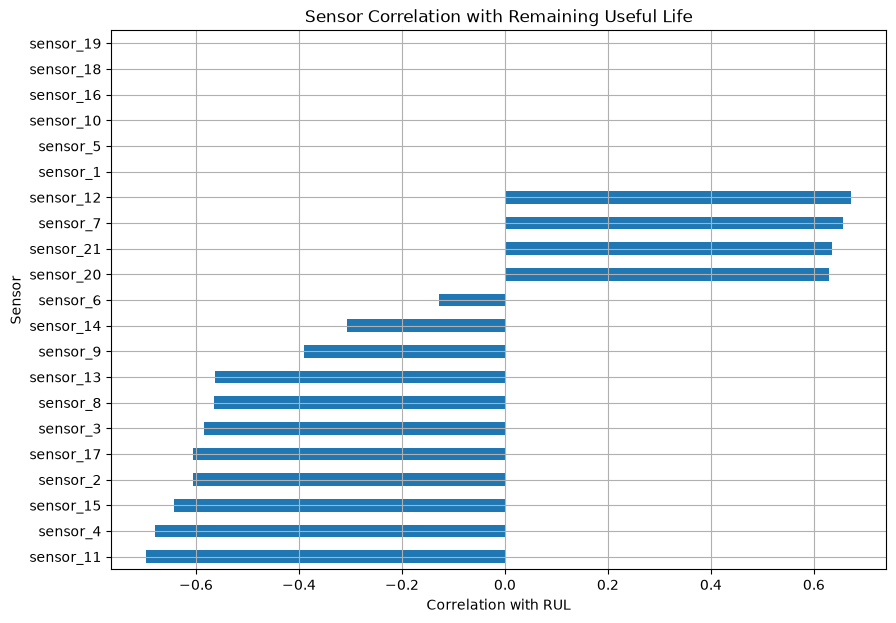

In [20]:
plt.figure(figsize=(10, 7))

correlations.plot(kind="barh")

plt.xlabel("Correlation with RUL")
plt.ylabel("Sensor")
plt.title("Sensor Correlation with Remaining Useful Life")

plt.grid(True)
plt.show()

In [21]:
# Sensors selected for the first RUL prediction model

selected_sensors = [
    "sensor_2",
    "sensor_3",
    "sensor_4",
    "sensor_7",
    "sensor_8",
    "sensor_9",
    "sensor_11",
    "sensor_12",
    "sensor_13",
    "sensor_14",
    "sensor_15",
    "sensor_17",
    "sensor_20",
    "sensor_21"
]

print("Selected sensors:")
print(selected_sensors)

print("\nNumber of selected sensors:", len(selected_sensors))

Selected sensors:
['sensor_2', 'sensor_3', 'sensor_4', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_17', 'sensor_20', 'sensor_21']

Number of selected sensors: 14


In [22]:
X = train_df[selected_sensors]
y = train_df["RUL"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (20631, 14)
y shape: (20631,)


In [23]:
from sklearn.model_selection import GroupShuffleSplit

gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=42
)

train_idx, val_idx = next(
    gss.split(
        X,
        y,
        groups=train_df["unit_id"]
    )
)

X_train = X.iloc[train_idx]
X_val = X.iloc[val_idx]

y_train = y.iloc[train_idx]
y_val = y.iloc[val_idx]

print("Training samples:", len(X_train))
print("Validation samples:", len(X_val))

print("\nTraining engines:",
      train_df.iloc[train_idx]["unit_id"].nunique())

print("Validation engines:",
      train_df.iloc[val_idx]["unit_id"].nunique())

Training samples: 16561
Validation samples: 4070

Training engines: 80
Validation engines: 20


In [24]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=200,
    max_depth=20,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

print("Random Forest training completed!")

Random Forest training completed!


In [25]:
y_pred = model.predict(X_val)

print("First 10 predictions:")
print(y_pred[:10])

First 10 predictions:
[163.33554174 176.85310036 178.47109271 203.17105861 168.8750713
 198.52303226 177.63230011 179.84889357 186.91987433 190.27701695]


In [26]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_val, y_pred)
rmse = np.sqrt(mean_squared_error(y_val, y_pred))
r2 = r2_score(y_val, y_pred)

print(f"MAE  : {mae:.2f} cycles")
print(f"RMSE : {rmse:.2f} cycles")
print(f"R²   : {r2:.4f}")

MAE  : 25.82 cycles
RMSE : 35.31 cycles
R²   : 0.7107


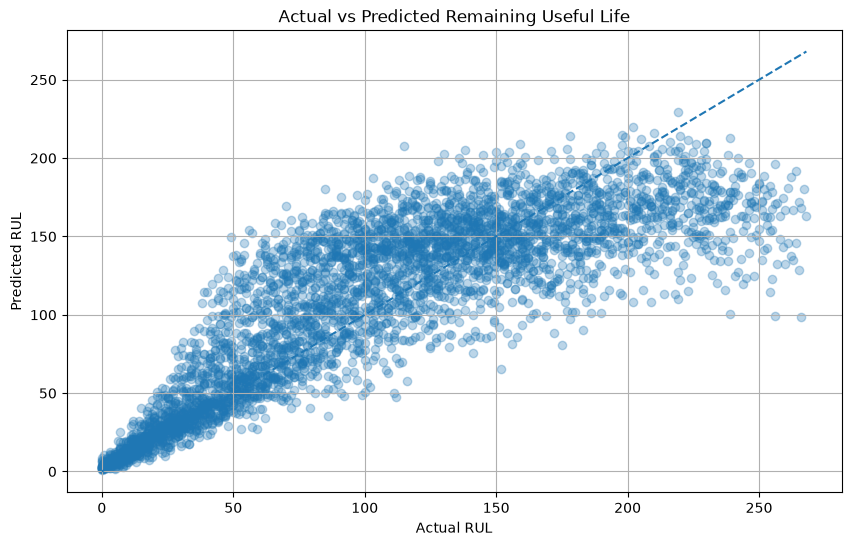

In [27]:
plt.figure(figsize=(10, 6))

plt.scatter(
    y_val,
    y_pred,
    alpha=0.3
)

plt.plot(
    [0, y_val.max()],
    [0, y_val.max()],
    linestyle="--"
)

plt.xlabel("Actual RUL")
plt.ylabel("Predicted RUL")
plt.title("Actual vs Predicted Remaining Useful Life")

plt.grid(True)
plt.show()

In [28]:
RUL_CAP = 125

train_df["RUL_capped"] = train_df["RUL"].clip(upper=RUL_CAP)

print(train_df["RUL_capped"].describe())

count    20631.000000
mean        86.829286
std         41.673699
min          0.000000
25%         51.000000
50%        103.000000
75%        125.000000
max        125.000000
Name: RUL_capped, dtype: float64


In [29]:
X = train_df[selected_sensors]
y = train_df["RUL_capped"]

gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=42
)

train_idx, val_idx = next(
    gss.split(
        X,
        y,
        groups=train_df["unit_id"]
    )
)

X_train = X.iloc[train_idx]
X_val = X.iloc[val_idx]

y_train = y.iloc[train_idx]
y_val = y.iloc[val_idx]

print("Training samples:", len(X_train))
print("Validation samples:", len(X_val))

Training samples: 16561
Validation samples: 4070


In [30]:
model_capped = RandomForestRegressor(
    n_estimators=300,
    max_depth=25,
    min_samples_split=4,
    min_samples_leaf=2,
    max_features="sqrt",
    random_state=42,
    n_jobs=-1
)

model_capped.fit(X_train, y_train)

print("Improved Random Forest trained!")

Improved Random Forest trained!


In [31]:
y_pred_capped = model_capped.predict(X_val)

mae_capped = mean_absolute_error(y_val, y_pred_capped)
rmse_capped = np.sqrt(mean_squared_error(y_val, y_pred_capped))
r2_capped = r2_score(y_val, y_pred_capped)

print(f"MAE  : {mae_capped:.2f} cycles")
print(f"RMSE : {rmse_capped:.2f} cycles")
print(f"R²   : {r2_capped:.4f}")

MAE  : 12.39 cycles
RMSE : 16.85 cycles
R²   : 0.8369


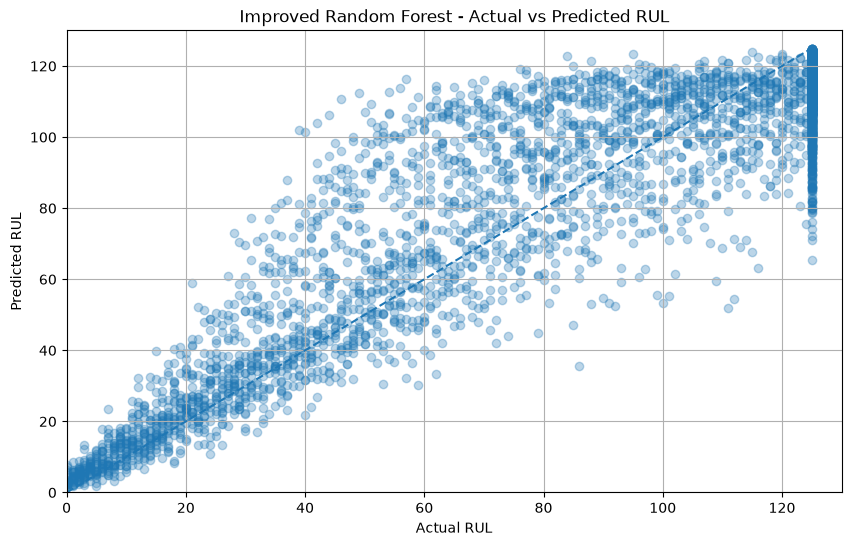

In [32]:
plt.figure(figsize=(10, 6))

plt.scatter(
    y_val,
    y_pred_capped,
    alpha=0.3
)

plt.plot(
    [0, 125],
    [0, 125],
    linestyle="--"
)

plt.xlabel("Actual RUL")
plt.ylabel("Predicted RUL")
plt.title("Improved Random Forest - Actual vs Predicted RUL")

plt.xlim(0, 130)
plt.ylim(0, 130)

plt.grid(True)
plt.show()

In [35]:
# Use the same sensors we used for training

X_test = test_df[selected_sensors]

print("Test data shape:", X_test.shape)

Test data shape: (13096, 14)


In [36]:
# Predict RUL for every test observation

test_predictions = model_capped.predict(X_test)

print("Number of predictions:", len(test_predictions))
print("First 10 predictions:")
print(test_predictions[:10])

Number of predictions: 13096
First 10 predictions:
[117.81380628 114.67335714 117.20394912 120.78159524 121.47431212
 120.69231229 119.5520172  119.54361083 115.11465873 122.73797443]


In [37]:
# Get the last recorded row for each test engine

last_test_rows = test_df.groupby("unit_id")["cycle"].idxmax()

test_last = test_df.loc[last_test_rows].copy()

print("Number of test engines:", len(test_last))
print(test_last[["unit_id", "cycle"]].head(10))

Number of test engines: 100
      unit_id  cycle
30          1     31
79          2     49
205         3    126
311         4    106
409         5     98
514         6    105
674         7    160
840         8    166
895         9     55
1087       10    192


In [38]:
X_test_final = test_last[selected_sensors]

test_rul_predictions = model_capped.predict(X_test_final)

# Add predictions to the dataframe
test_last["Predicted_RUL"] = test_rul_predictions

print(
    test_last[
        ["unit_id", "cycle", "Predicted_RUL"]
    ].head(10)
)

      unit_id  cycle  Predicted_RUL
30          1     31     116.334936
79          2     49     115.442284
205         3    126      63.585429
311         4    106      84.345647
409         5     98     104.665115
514         6    105     104.405265
674         7    160     102.936003
840         8    166      93.846226
895         9     55     105.044716
1087       10    192     105.476104


In [39]:
actual_rul = rul_df["RUL"].values

# The model was trained with RUL capped at 125,
# so cap predictions for comparison.

predicted_rul = np.clip(
    test_last["Predicted_RUL"].values,
    0,
    125
)

print("Actual RUL:", actual_rul[:10])
print("Predicted RUL:", predicted_rul[:10])

Actual RUL: [112  98  69  82  91  93  91  95 111  96]
Predicted RUL: [116.33493609 115.44228351  63.58542857  84.34564683 104.66511508
 104.40526485 102.93600265  93.84622584 105.04471593 105.47610362]


In [40]:
test_mae = mean_absolute_error(
    actual_rul,
    predicted_rul
)

test_rmse = np.sqrt(
    mean_squared_error(
        actual_rul,
        predicted_rul
    )
)

test_r2 = r2_score(
    actual_rul,
    predicted_rul
)

print(f"Test MAE  : {test_mae:.2f} cycles")
print(f"Test RMSE : {test_rmse:.2f} cycles")
print(f"Test R²   : {test_r2:.4f}")

Test MAE  : 12.60 cycles
Test RMSE : 17.39 cycles
Test R²   : 0.8248


In [41]:
def calculate_health_score(rul):
    """
    Convert predicted RUL into a 0-100 health score.
    125 cycles or more = 100% health.
    """

    health = (rul / 125) * 100

    return np.clip(health, 0, 100)


test_last["Health_Score"] = (
    test_last["Predicted_RUL"]
    .apply(calculate_health_score)
)

test_last[
    ["unit_id", "Predicted_RUL", "Health_Score"]
].head(10)

,unit_id,Predicted_RUL,Health_Score
30,1,116.334936,93.067949
79,2,115.442284,92.353827
205,3,63.585429,50.868343
311,4,84.345647,67.476517
409,5,104.665115,83.732092
514,6,104.405265,83.524212
674,7,102.936003,82.348802
840,8,93.846226,75.076981
895,9,105.044716,84.035773
1087,10,105.476104,84.380883


In [42]:
def classify_risk(rul):

    if rul < 15:
        return "CRITICAL"

    elif rul < 40:
        return "HIGH"

    elif rul < 75:
        return "MODERATE"

    else:
        return "LOW"


test_last["Risk_Level"] = (
    test_last["Predicted_RUL"]
    .apply(classify_risk)
)

test_last[
    ["unit_id", "Predicted_RUL", "Health_Score", "Risk_Level"]
].head(20)

,unit_id,Predicted_RUL,Health_Score,Risk_Level
30,1,116.334936,93.067949,LOW
79,2,115.442284,92.353827,LOW
205,3,63.585429,50.868343,MODERATE
311,4,84.345647,67.476517,LOW
409,5,104.665115,83.732092,LOW
514,6,104.405265,83.524212,LOW
674,7,102.936003,82.348802,LOW
840,8,93.846226,75.076981,LOW
895,9,105.044716,84.035773,LOW
1087,10,105.476104,84.380883,LOW


In [43]:
def maintenance_recommendation(risk):

    if risk == "CRITICAL":
        return "Immediate maintenance required"

    elif risk == "HIGH":
        return "Schedule maintenance soon"

    elif risk == "MODERATE":
        return "Increase monitoring"

    else:
        return "Normal operation"


test_last["Maintenance_Action"] = (
    test_last["Risk_Level"]
    .apply(maintenance_recommendation)
)

test_last[
    [
        "unit_id",
        "Predicted_RUL",
        "Health_Score",
        "Risk_Level",
        "Maintenance_Action"
    ]
].head(20)

,unit_id,Predicted_RUL,Health_Score,Risk_Level,Maintenance_Action
30,1,116.334936,93.067949,LOW,Normal operation
79,2,115.442284,92.353827,LOW,Normal operation
205,3,63.585429,50.868343,MODERATE,Increase monitoring
311,4,84.345647,67.476517,LOW,Normal operation
409,5,104.665115,83.732092,LOW,Normal operation
514,6,104.405265,83.524212,LOW,Normal operation
674,7,102.936003,82.348802,LOW,Normal operation
840,8,93.846226,75.076981,LOW,Normal operation
895,9,105.044716,84.035773,LOW,Normal operation
1087,10,105.476104,84.380883,LOW,Normal operation


In [44]:
risk_counts = test_last["Risk_Level"].value_counts()

print(risk_counts)

Risk_Level
LOW         58
MODERATE    20
HIGH        15
CRITICAL     7
Name: count, dtype: int64


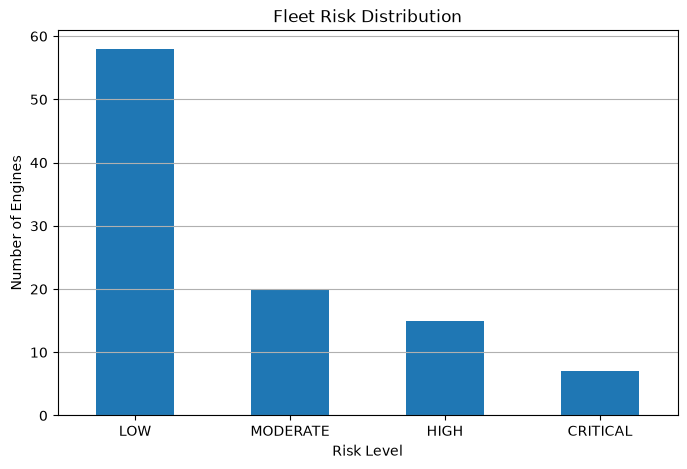

In [45]:
plt.figure(figsize=(8, 5))

risk_counts.plot(kind="bar")

plt.xlabel("Risk Level")
plt.ylabel("Number of Engines")
plt.title("Fleet Risk Distribution")

plt.xticks(rotation=0)
plt.grid(axis="y")

plt.show()

In [46]:
from sklearn.ensemble import IsolationForest

In [47]:
anomaly_model = IsolationForest(
    n_estimators=200,
    contamination=0.05,
    random_state=42,
    n_jobs=-1
)

anomaly_model.fit(train_df[selected_sensors])

print("Anomaly detection model trained!")

Anomaly detection model trained!


In [48]:
test_last["Anomaly"] = anomaly_model.predict(
    test_last[selected_sensors]
)

test_last["Anomaly_Status"] = test_last["Anomaly"].map({
    1: "NORMAL",
    -1: "ANOMALY"
})

print(test_last["Anomaly_Status"].value_counts())

Anomaly_Status
NORMAL     99
ANOMALY     1
Name: count, dtype: int64


In [50]:
test_last["Alert"] = np.where(
    (test_last["Risk_Level"].isin(["HIGH", "CRITICAL"])) |
    (test_last["Anomaly_Status"] == "ANOMALY"),
    "ATTENTION REQUIRED",
    "NORMAL"
)

test_last[
    [
        "unit_id",
        "Predicted_RUL",
        "Health_Score",
        "Risk_Level",
        "Anomaly_Status",
        "Alert"
    ]
].head(20)

,unit_id,Predicted_RUL,Health_Score,Risk_Level,Anomaly_Status,Alert
30,1,116.334936,93.067949,LOW,NORMAL,NORMAL
79,2,115.442284,92.353827,LOW,NORMAL,NORMAL
205,3,63.585429,50.868343,MODERATE,NORMAL,NORMAL
311,4,84.345647,67.476517,LOW,NORMAL,NORMAL
409,5,104.665115,83.732092,LOW,NORMAL,NORMAL
514,6,104.405265,83.524212,LOW,NORMAL,NORMAL
674,7,102.936003,82.348802,LOW,NORMAL,NORMAL
840,8,93.846226,75.076981,LOW,NORMAL,NORMAL
895,9,105.044716,84.035773,LOW,NORMAL,NORMAL
1087,10,105.476104,84.380883,LOW,NORMAL,NORMAL


In [51]:
fleet_summary = {
    "Total Engines": len(test_last),
    "Low Risk": (test_last["Risk_Level"] == "LOW").sum(),
    "Moderate Risk": (test_last["Risk_Level"] == "MODERATE").sum(),
    "High Risk": (test_last["Risk_Level"] == "HIGH").sum(),
    "Critical Risk": (test_last["Risk_Level"] == "CRITICAL").sum(),
    "Anomalies": (test_last["Anomaly_Status"] == "ANOMALY").sum(),
    "Attention Required": (
        test_last["Alert"] == "ATTENTION REQUIRED"
    ).sum()
}

for key, value in fleet_summary.items():
    print(f"{key}: {value}")

Total Engines: 100
Low Risk: 58
Moderate Risk: 20
High Risk: 15
Critical Risk: 7
Anomalies: 1
Attention Required: 22


In [52]:
high_risk_engines = test_last.sort_values(
    "Predicted_RUL"
)[
    [
        "unit_id",
        "cycle",
        "Predicted_RUL",
        "Health_Score",
        "Risk_Level",
        "Anomaly_Status",
        "Maintenance_Action"
    ]
]

high_risk_engines.head(10)

,unit_id,cycle,Predicted_RUL,Health_Score,Risk_Level,Anomaly_Status,Maintenance_Action
4267,34,203,6.397030,5.117624,CRITICAL,ANOMALY,Immediate maintenance required
10600,81,213,7.728714,6.182971,CRITICAL,NORMAL,Immediate maintenance required
4465,35,198,8.638667,6.910933,CRITICAL,NORMAL,Immediate maintenance required
10762,82,162,9.644352,7.715481,CRITICAL,NORMAL,Immediate maintenance required
9919,76,205,13.886726,11.109381,CRITICAL,NORMAL,Immediate maintenance required
7205,56,136,13.996455,11.197164,CRITICAL,NORMAL,Immediate maintenance required
6264,49,303,14.516394,11.613115,CRITICAL,NORMAL,Immediate maintenance required
8714,66,147,15.524099,12.419279,HIGH,NORMAL,Schedule maintenance soon
13095,100,198,17.810955,14.248764,HIGH,NORMAL,Schedule maintenance soon
8972,68,187,18.772759,15.018207,HIGH,NORMAL,Schedule maintenance soon


In [53]:
feature_importance = pd.DataFrame({
    "Sensor": selected_sensors,
    "Importance": model_capped.feature_importances_
})

feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False
)

feature_importance

,Sensor,Importance
6,sensor_11,0.171729
2,sensor_4,0.152759
7,sensor_12,0.133117
10,sensor_15,0.088291
3,sensor_7,0.084451
5,sensor_9,0.076341
13,sensor_21,0.063917
9,sensor_14,0.061267
12,sensor_20,0.052614
0,sensor_2,0.032080


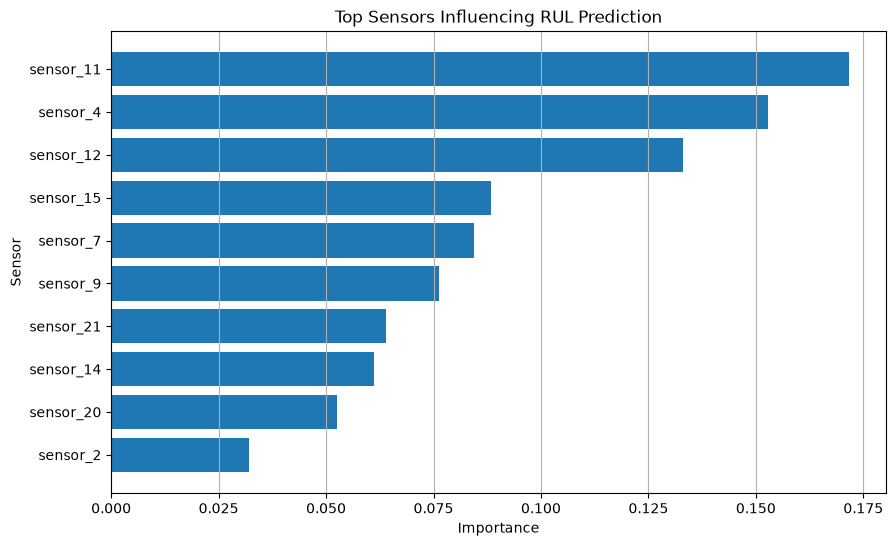

In [54]:
plt.figure(figsize=(10, 6))

top_features = feature_importance.head(10)

plt.barh(
    top_features["Sensor"][::-1],
    top_features["Importance"][::-1]
)

plt.xlabel("Importance")
plt.ylabel("Sensor")
plt.title("Top Sensors Influencing RUL Prediction")

plt.grid(axis="x")

plt.show()

In [55]:
model_summary = {
    "Model": "Random Forest Regressor",
    "Dataset": "NASA C-MAPSS FD001",
    "Features": len(selected_sensors),
    "Test MAE": round(test_mae, 2),
    "Test RMSE": round(test_rmse, 2),
    "Test R2": round(test_r2, 4),
    "Anomaly Detection": "Isolation Forest"
}

model_summary

{'Model': 'Random Forest Regressor',
 'Dataset': 'NASA C-MAPSS FD001',
 'Features': 14,
 'Test MAE': 12.6,
 'Test RMSE': np.float64(17.39),
 'Test R2': 0.8248,
 'Anomaly Detection': 'Isolation Forest'}

In [56]:
import joblib
import os

os.makedirs("models", exist_ok=True)

joblib.dump(
    model_capped,
    "models/rul_model.pkl"
)

print("RUL model saved successfully!")

RUL model saved successfully!


In [57]:
joblib.dump(
    anomaly_model,
    "models/anomaly_model.pkl"
)

print("Anomaly model saved successfully!")

Anomaly model saved successfully!


In [58]:
model_config = {
    "selected_sensors": selected_sensors,
    "rul_cap": RUL_CAP,
    "risk_thresholds": {
        "critical": 15,
        "high": 40,
        "moderate": 75
    }
}

joblib.dump(
    model_config,
    "models/model_config.pkl"
)

print("Model configuration saved successfully!")

Model configuration saved successfully!


In [59]:
loaded_rul_model = joblib.load(
    "models/rul_model.pkl"
)

loaded_anomaly_model = joblib.load(
    "models/anomaly_model.pkl"
)

loaded_config = joblib.load(
    "models/model_config.pkl"
)

print("All models loaded successfully!")
print("Sensors:", loaded_config["selected_sensors"])

All models loaded successfully!
Sensors: ['sensor_2', 'sensor_3', 'sensor_4', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_17', 'sensor_20', 'sensor_21']


In [63]:
# Take one real engine observation from the test set
sample = test_last.iloc[0]

sample_sensor_data = {
    sensor: sample[sensor]
    for sensor in selected_sensors
}

result = predict_aircraft_health(sample_sensor_data)

print(result)

{'predicted_rul': 116.33, 'health_score': 93.07, 'risk_level': 'LOW', 'anomaly_status': 'NORMAL', 'alert': 'NORMAL', 'maintenance_action': 'Normal operation'}


In [64]:
def predict_aircraft_health(sensor_data):
    """
    Predict aircraft/engine health from sensor readings.

    sensor_data should be a dictionary containing
    the 14 required sensor values.
    """

    # Load configuration
    sensors = loaded_config["selected_sensors"]
    rul_cap = loaded_config["rul_cap"]

    # Create input DataFrame in the correct sensor order
    input_data = pd.DataFrame(
        [[sensor_data[sensor] for sensor in sensors]],
        columns=sensors
    )

    # Predict Remaining Useful Life
    predicted_rul = loaded_rul_model.predict(input_data)[0]

    # Keep RUL within valid range
    predicted_rul = float(
        np.clip(predicted_rul, 0, rul_cap)
    )

    # Calculate health score
    health_score = (predicted_rul / rul_cap) * 100

    # Risk classification
    if predicted_rul < 15:
        risk_level = "CRITICAL"
        maintenance_action = "Immediate maintenance required"

    elif predicted_rul < 40:
        risk_level = "HIGH"
        maintenance_action = "Schedule maintenance soon"

    elif predicted_rul < 75:
        risk_level = "MODERATE"
        maintenance_action = "Increase monitoring"

    else:
        risk_level = "LOW"
        maintenance_action = "Normal operation"

    # Anomaly detection
    anomaly_prediction = loaded_anomaly_model.predict(
        input_data
    )[0]

    anomaly_status = (
        "ANOMALY"
        if anomaly_prediction == -1
        else "NORMAL"
    )

    # Overall alert
    if risk_level in ["HIGH", "CRITICAL"] or anomaly_status == "ANOMALY":
        alert = "ATTENTION REQUIRED"
    else:
        alert = "NORMAL"

    return {
        "predicted_rul": round(predicted_rul, 2),
        "health_score": round(health_score, 2),
        "risk_level": risk_level,
        "anomaly_status": anomaly_status,
        "alert": alert,
        "maintenance_action": maintenance_action
    }

In [65]:
print("====================================")
print("        AEROGUARD HEALTH REPORT")
print("====================================")

print(f"Predicted RUL      : {result['predicted_rul']} cycles")
print(f"Health Score       : {result['health_score']}%")
print(f"Risk Level         : {result['risk_level']}")
print(f"Anomaly Status     : {result['anomaly_status']}")
print(f"Alert              : {result['alert']}")
print(f"Recommendation     : {result['maintenance_action']}")

print("====================================")

        AEROGUARD HEALTH REPORT
Predicted RUL      : 116.33 cycles
Health Score       : 93.07%
Risk Level         : LOW
Anomaly Status     : NORMAL
Alert              : NORMAL
Recommendation     : Normal operation


In [66]:
result = predict_aircraft_health(sample_sensor_data)

In [68]:
# Create a fictional aircraft fleet from our test engines

fleet_df = test_last.copy()

# Give the engines fictional aircraft IDs
fleet_df["aircraft_id"] = [
    f"AG-{i:03d}"
    for i in range(1, len(fleet_df) + 1)
]

# Put aircraft ID first
cols = ["aircraft_id"] + [
    col for col in fleet_df.columns
    if col != "aircraft_id"
]

fleet_df = fleet_df[cols]

fleet_df[
    [
        "aircraft_id",
        "Predicted_RUL",
        "Health_Score",
        "Risk_Level",
        "Anomaly_Status",
        "Alert"
    ]
    
].head(10)

,aircraft_id,Predicted_RUL,Health_Score,Risk_Level,Anomaly_Status,Alert
30,AG-001,116.334936,93.067949,LOW,NORMAL,NORMAL
79,AG-002,115.442284,92.353827,LOW,NORMAL,NORMAL
205,AG-003,63.585429,50.868343,MODERATE,NORMAL,NORMAL
311,AG-004,84.345647,67.476517,LOW,NORMAL,NORMAL
409,AG-005,104.665115,83.732092,LOW,NORMAL,NORMAL
514,AG-006,104.405265,83.524212,LOW,NORMAL,NORMAL
674,AG-007,102.936003,82.348802,LOW,NORMAL,NORMAL
840,AG-008,93.846226,75.076981,LOW,NORMAL,NORMAL
895,AG-009,105.044716,84.035773,LOW,NORMAL,NORMAL
1087,AG-010,105.476104,84.380883,LOW,NORMAL,NORMAL


In [69]:
def determine_availability(row):

    if row["Risk_Level"] == "CRITICAL":
        return "UNDER MAINTENANCE"

    elif row["Risk_Level"] == "HIGH":
        return "AVAILABLE - MAINTENANCE SCHEDULED"

    elif row["Risk_Level"] == "MODERATE":
        return "AVAILABLE - MONITORING"

    else:
        return "AVAILABLE"


fleet_df["Availability_Status"] = fleet_df.apply(
    determine_availability,
    axis=1
)

fleet_df[
    [
        "aircraft_id",
        "Risk_Level",
        "Availability_Status"
    ]
].head(20)

,aircraft_id,Risk_Level,Availability_Status
30,AG-001,LOW,AVAILABLE
79,AG-002,LOW,AVAILABLE
205,AG-003,MODERATE,AVAILABLE - MONITORING
311,AG-004,LOW,AVAILABLE
409,AG-005,LOW,AVAILABLE
514,AG-006,LOW,AVAILABLE
674,AG-007,LOW,AVAILABLE
840,AG-008,LOW,AVAILABLE
895,AG-009,LOW,AVAILABLE
1087,AG-010,LOW,AVAILABLE


In [70]:
total_aircraft = len(fleet_df)

available_aircraft = (
    fleet_df["Availability_Status"] != "UNDER MAINTENANCE"
).sum()

maintenance_aircraft = (
    fleet_df["Availability_Status"] == "UNDER MAINTENANCE"
).sum()

availability_percentage = (
    available_aircraft / total_aircraft
) * 100

print("====================================")
print("       AEROGUARD FLEET STATUS")
print("====================================")

print(f"Total Aircraft       : {total_aircraft}")
print(f"Available Aircraft   : {available_aircraft}")
print(f"Under Maintenance    : {maintenance_aircraft}")
print(f"Fleet Availability   : {availability_percentage:.2f}%")

print("====================================")

       AEROGUARD FLEET STATUS
Total Aircraft       : 100
Available Aircraft   : 93
Under Maintenance    : 7
Fleet Availability   : 93.00%


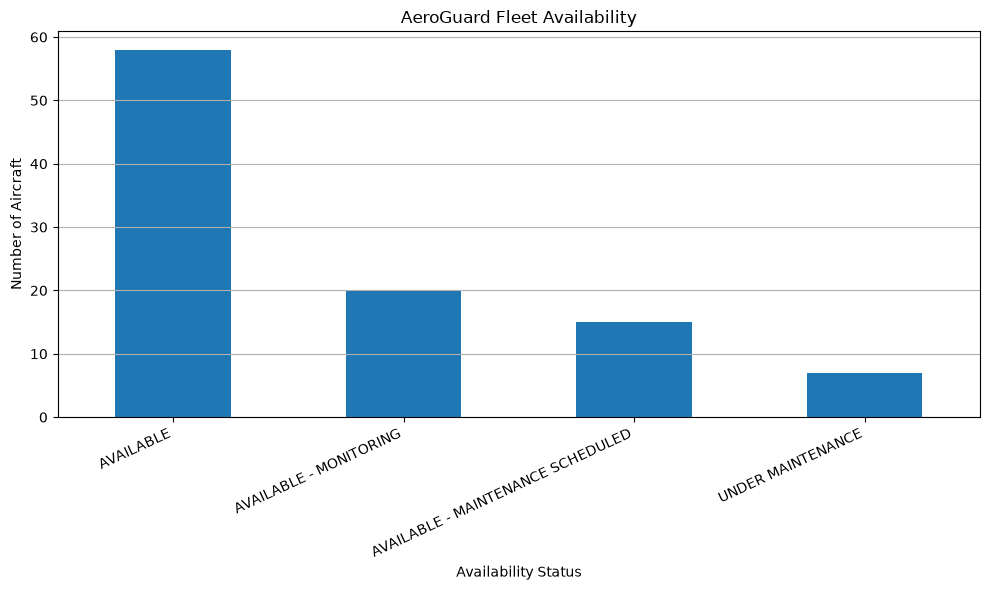

In [71]:
availability_counts = fleet_df[
    "Availability_Status"
].value_counts()

plt.figure(figsize=(10, 6))

availability_counts.plot(kind="bar")

plt.xlabel("Availability Status")
plt.ylabel("Number of Aircraft")
plt.title("AeroGuard Fleet Availability")

plt.xticks(rotation=25, ha="right")
plt.grid(axis="y")

plt.tight_layout()
plt.show()

In [72]:
fleet_dashboard = {
    "total_aircraft": int(total_aircraft),
    "available_aircraft": int(available_aircraft),
    "under_maintenance": int(maintenance_aircraft),
    "availability_percentage": round(
        availability_percentage, 2
    ),
    "low_risk": int(
        (fleet_df["Risk_Level"] == "LOW").sum()
    ),
    "moderate_risk": int(
        (fleet_df["Risk_Level"] == "MODERATE").sum()
    ),
    "high_risk": int(
        (fleet_df["Risk_Level"] == "HIGH").sum()
    ),
    "critical_risk": int(
        (fleet_df["Risk_Level"] == "CRITICAL").sum()
    ),
    "anomalies": int(
        (fleet_df["Anomaly_Status"] == "ANOMALY").sum()
    )
}

fleet_dashboard

{'total_aircraft': 100,
 'available_aircraft': 93,
 'under_maintenance': 7,
 'availability_percentage': np.float64(93.0),
 'low_risk': 58,
 'moderate_risk': 20,
 'high_risk': 15,
 'critical_risk': 7,
 'anomalies': 1}

In [73]:
import numpy as np

np.random.seed(42)

def maintenance_duration(risk):

    if risk == "CRITICAL":
        return np.random.randint(5, 11)

    elif risk == "HIGH":
        return np.random.randint(3, 7)

    elif risk == "MODERATE":
        return np.random.randint(1, 4)

    else:
        return 0


fleet_df["Maintenance_Days"] = fleet_df["Risk_Level"].apply(
    maintenance_duration
)

fleet_df[
    [
        "aircraft_id",
        "Risk_Level",
        "Predicted_RUL",
        "Maintenance_Days"
    ]
].head(20)

,aircraft_id,Risk_Level,Predicted_RUL,Maintenance_Days
30,AG-001,LOW,116.334936,0
79,AG-002,LOW,115.442284,0
205,AG-003,MODERATE,63.585429,3
311,AG-004,LOW,84.345647,0
409,AG-005,LOW,104.665115,0
514,AG-006,LOW,104.405265,0
674,AG-007,LOW,102.936003,0
840,AG-008,LOW,93.846226,0
895,AG-009,LOW,105.044716,0
1087,AG-010,LOW,105.476104,0


In [74]:
maintenance_workload = fleet_df[
    fleet_df["Maintenance_Days"] > 0
][
    [
        "aircraft_id",
        "Risk_Level",
        "Predicted_RUL",
        "Maintenance_Days"
    ]
].sort_values(
    "Maintenance_Days",
    ascending=False
)

print("Aircraft requiring maintenance:")
print(len(maintenance_workload))

print("\nTotal maintenance workload:")
print(
    maintenance_workload["Maintenance_Days"].sum(),
    "aircraft-days"
)

Aircraft requiring maintenance:
42

Total maintenance workload:
163 aircraft-days


In [75]:
risk_priority = {
    "CRITICAL": 4,
    "HIGH": 3,
    "MODERATE": 2,
    "LOW": 1
}

fleet_df["Priority_Score"] = fleet_df["Risk_Level"].map(
    risk_priority
)

maintenance_priority = fleet_df[
    fleet_df["Maintenance_Days"] > 0
].sort_values(
    ["Priority_Score", "Predicted_RUL"],
    ascending=[False, True]
)

maintenance_priority[
    [
        "aircraft_id",
        "Predicted_RUL",
        "Risk_Level",
        "Maintenance_Days",
        "Priority_Score"
    ]
].head(15)

,aircraft_id,Predicted_RUL,Risk_Level,Maintenance_Days,Priority_Score
4267,AG-034,6.397030,CRITICAL,7,4
10600,AG-081,7.728714,CRITICAL,8,4
4465,AG-035,8.638667,CRITICAL,7,4
10762,AG-082,9.644352,CRITICAL,8,4
9919,AG-076,13.886726,CRITICAL,6,4
7205,AG-056,13.996455,CRITICAL,9,4
6264,AG-049,14.516394,CRITICAL,6,4
8714,AG-066,15.524099,HIGH,3,3
13095,AG-100,17.810955,HIGH,6,3
8972,AG-068,18.772759,HIGH,5,3


In [77]:
forecast_days = 7

daily_forecast = []

for day in range(1, forecast_days + 1):

    under_maintenance = (
        (fleet_df["Maintenance_Days"] >= day) &
        (fleet_df["Maintenance_Days"] > 0)
    ).sum()

    available = total_aircraft - under_maintenance

    availability = (
        available / total_aircraft
    ) * 100

    daily_forecast.append({
        "Day": day,
        "Available_Aircraft": available,
        "Under_Maintenance": under_maintenance,
        "Availability_Percentage": availability
    })

forecast_df = pd.DataFrame(daily_forecast)

print("7-day forecast created successfully!")
display(forecast_df)

7-day forecast created successfully!


,Day,Available_Aircraft,Under_Maintenance,Availability_Percentage
0,1,58,42,58.0
1,2,65,35,65.0
2,3,71,29,71.0
3,4,80,20,80.0
4,5,84,16,84.0
5,6,88,12,88.0
6,7,95,5,95.0


In [78]:
print("====================================")
print("   7-DAY FLEET AVAILABILITY FORECAST")
print("====================================")

for _, row in forecast_df.iterrows():

    print(
        f"Day {int(row['Day'])}: "
        f"{int(row['Available_Aircraft'])} available | "
        f"{int(row['Under_Maintenance'])} maintenance | "
        f"{row['Availability_Percentage']:.1f}% availability"
    )

print("====================================")

   7-DAY FLEET AVAILABILITY FORECAST
Day 1: 58 available | 42 maintenance | 58.0% availability
Day 2: 65 available | 35 maintenance | 65.0% availability
Day 3: 71 available | 29 maintenance | 71.0% availability
Day 4: 80 available | 20 maintenance | 80.0% availability
Day 5: 84 available | 16 maintenance | 84.0% availability
Day 6: 88 available | 12 maintenance | 88.0% availability
Day 7: 95 available | 5 maintenance | 95.0% availability


In [79]:
sample = test_last.iloc[0]

for sensor in selected_sensors:
    print(f'"{sensor}": {sample[sensor]},')

"sensor_2": 642.58,
"sensor_3": 1581.22,
"sensor_4": 1398.91,
"sensor_7": 554.42,
"sensor_8": 2388.08,
"sensor_9": 9056.4,
"sensor_11": 47.23,
"sensor_12": 521.79,
"sensor_13": 2388.06,
"sensor_14": 8130.11,
"sensor_15": 8.4024,
"sensor_17": 393,
"sensor_20": 38.81,
"sensor_21": 23.3552,


In [80]:
sample = test_last.iloc[0]

for sensor in selected_sensors:
    print(f'"{sensor}": {sample[sensor]},')

"sensor_2": 642.58,
"sensor_3": 1581.22,
"sensor_4": 1398.91,
"sensor_7": 554.42,
"sensor_8": 2388.08,
"sensor_9": 9056.4,
"sensor_11": 47.23,
"sensor_12": 521.79,
"sensor_13": 2388.06,
"sensor_14": 8130.11,
"sensor_15": 8.4024,
"sensor_17": 393,
"sensor_20": 38.81,
"sensor_21": 23.3552,
